In [20]:
'''
select :
Anthracnose
Downy Mildew
Powdery Mildew
Leaf Miner damage
Fresh Leaf (Healthy leaf class)

from the Dataset available at location : /kaggle/input/cucumber-disease-recognition-dataset/Cucumber Disease Recognition Dataset/Original Image/Original Image
step 1: preprocess 
step 2: Build the following models (Multi Label Classification):
| Type     | Model                      | Role in Project            |
| -------- | -------------------------- | -------------------------- |
| Base     | ResNet50                   | Deep lesion understanding  |
| Base     | InceptionV3                | Multi-scale spot detection |
| Base     | EfficientNetB0             | Efficient high accuracy    |
| Base     | MobileNet                  | Real-time speed            |
| Hybrid-1 | ResNet50 + InceptionV3     | Highest accuracy           |
| Hybrid-2 | ResNet50 + EfficientNetB0  | Best balance               |
| Hybrid-3 | MobileNet + EfficientNetB0 | Best for real-time         |

step 3: train and save weights of best accuracy of each model.  
step 4: visualize confusion matrix for each model, learning curve using training loss or validation loss, precision,recall,f1 score, auc etcc for each model, create a visually apealing comparision table for each model. 
step 5: Implemeny function to test with new images.
step 6: Implement function to test with live camera capture image.

Note: Use avaiable gpu to speed up the process. 

SyntaxError: incomplete input (445556140.py, line 1)

In [21]:
import os
import cv2
import shutil
from tqdm import tqdm

# --- CONFIGURATION ---

# Paths (Based on your Kaggle environment)
DS1_ROOT = "/kaggle/input/cucumber-disease-recognition-dataset/cucumberleaf"
DS2_ROOT = "/kaggle/input/datasets/spise/new-given-dataset/cucumber_Leaf_Disease11"

# Output settings
WORKING_DIR = "/kaggle/working"
TEMP_DIR = os.path.join(WORKING_DIR, "temp_cucumber_data")
ZIP_NAME = "cucumber_dataset_processed"  # Will become cucumber_dataset_processed.zip
IMG_SIZE = (224, 224) 

# The specific classes you want to extract and merge
TARGET_CLASSES = [
    'Anthracnose lesions', 
    'Downy Mildew', 
    'Healthy_leaves', 
    'Leaf Miner', 
    'Powdery_mildew'
]

# --- FOLDER MAPPING ---
# Maps source folder names to the standardized TARGET_CLASSES
FOLDER_MAP = {
    # Dataset 1 (Cucumber Disease Recognition Dataset)
    "Anthracnose": "Anthracnose lesions",
    "Downy Mildew": "Downy Mildew",
    "Fresh Leaf": "Healthy_leaves",
    "Fresh Cucumber": "Healthy_leaves", # Optional: Include if you consider fresh cucumbers as healthy
    
    # Dataset 2 (cucumber_Leaf_Disease11)
    "Anthracnose lesions": "Anthracnose lesions",
    "Downy_mildew": "Downy Mildew",
    "Healthy_leaves": "Healthy_leaves",
    "Leaf Miner": "Leaf Miner",
    "Powdery_mildew": "Powdery_mildew"
}

def create_temp_structure():
    """Creates the temporary directory tree."""
    if os.path.exists(TEMP_DIR):
        shutil.rmtree(TEMP_DIR)
    os.makedirs(TEMP_DIR)
    
    for cls in TARGET_CLASSES:
        os.makedirs(os.path.join(TEMP_DIR, cls), exist_ok=True)

def process_image(src_path, target_class, prefix, counter):
    """Reads, resizes, and saves image to the temp directory."""
    try:
        img = cv2.imread(src_path)
        if img is None: return False
        
        # Resize standardizes the shape
        img = cv2.resize(img, IMG_SIZE)
        
        # Create unique filename: e.g., ds1_Anthracnose_0.jpg
        filename = f"{prefix}_{target_class}_{counter}.jpg"
        dst_path = os.path.join(TEMP_DIR, target_class, filename)
        
        cv2.imwrite(dst_path, img)
        return True
    except Exception as e:
        return False

def run_pipeline():
    print(f"1. Creating temporary structure at {TEMP_DIR}...")
    create_temp_structure()
    
    total_images = 0
    
    # --- PROCESS DATASET 1 ---
    print("2. Processing Dataset 1...")
    ds1_count = 0
    for root, dirs, files in os.walk(DS1_ROOT):
        folder_name = os.path.basename(root)
        
        if folder_name in FOLDER_MAP and FOLDER_MAP[folder_name] in TARGET_CLASSES:
            target = FOLDER_MAP[folder_name]
            # Filter for images only
            valid_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            
            for f in tqdm(valid_files, desc=f"  Merging {folder_name} -> {target}", leave=False):
                if process_image(os.path.join(root, f), target, "ds1", ds1_count):
                    ds1_count += 1
                    total_images += 1

    # --- PROCESS DATASET 2 ---
    print("3. Processing Dataset 2...")
    ds2_count = 0
    for root, dirs, files in os.walk(DS2_ROOT):
        folder_name = os.path.basename(root)
        
        if folder_name in FOLDER_MAP and FOLDER_MAP[folder_name] in TARGET_CLASSES:
            target = FOLDER_MAP[folder_name]
            valid_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            
            for f in tqdm(valid_files, desc=f"  Merging {folder_name} -> {target}", leave=False):
                if process_image(os.path.join(root, f), target, "ds2", ds2_count):
                    ds2_count += 1
                    total_images += 1

    # --- ZIPPING ---
    print(f"\n4. Zipping data... ({total_images} images processed)")
    output_zip_path = os.path.join(WORKING_DIR, ZIP_NAME)
    shutil.make_archive(output_zip_path, 'zip', TEMP_DIR)
    
    # --- CLEANUP ---
    print("5. Cleaning up temporary files...")
    shutil.rmtree(TEMP_DIR)
    
    print(f"\nSUCCESS! Download your dataset here: {output_zip_path}.zip")

if __name__ == "__main__":
    run_pipeline()

1. Creating temporary structure at /kaggle/working/temp_cucumber_data...
2. Processing Dataset 1...


KeyboardInterrupt: 

In [ ]:
import os
import cv2
import glob
from tqdm import tqdm
from pathlib import Path
import shutil

# --- CONFIGURATION ---

# Defined Paths (Based on your Kaggle environment)
DS1_ROOT = "/kaggle/input/cucumber-disease-recognition-dataset/Cucumber Disease Recognition Dataset"
DS2_ROOT = "/kaggle/input/datasets/pisesravani/new-given-dataset/cucumberleaf"
OUTPUT_DIR = "/kaggle/working/Processed_Cucumber_Dataset"

# The final classes you want
TARGET_CLASSES = [
    'Anthracnose lesions', 
    'Downy Mildew', 
    'Healthy_leaves', 
    'Leaf Miner', 
    'Powdery_mildew'
]

# Image settings
IMG_SIZE = (224, 224) # Standard input size for models like ResNet/MobileNet

# --- CLASS MAPPING ---
# This dictionary maps specific folder names found in the source datasets 
# to your desired TARGET_CLASSES. 
# Key = Source Folder Name, Value = Target Class Name
FOLDER_MAP = {
    # Dataset 1 Mappings
    "Anthracnose": "Anthracnose lesions",
    "Downy Mildew": "Downy Mildew",
    "Fresh Leaf": "Healthy_leaves",
    
    # Dataset 2 Mappings (Exact matches or slight variations)
    "Anthracnose lesions": "Anthracnose lesions",
    "Downy_mildew": "Downy Mildew", # Mapping underscore to space
    "Healthy_leaves": "Healthy_leaves",
    "Leaf Miner": "Leaf Miner",
    "Powdery_mildew": "Powdery_mildew"
}

def create_dir_structure():
    """Creates the target directory structure."""
    if os.path.exists(OUTPUT_DIR):
        shutil.rmtree(OUTPUT_DIR)
    os.makedirs(OUTPUT_DIR)
    
    for cls in TARGET_CLASSES:
        os.makedirs(os.path.join(OUTPUT_DIR, cls), exist_ok=True)
    print(f"Created output directory at: {OUTPUT_DIR}")

def process_and_copy_image(src_path, target_class, img_counter, prefix):
    """Reads, resizes, and saves an image."""
    try:
        # Read image
        img = cv2.imread(src_path)
        if img is None:
            return False
            
        # Resize
        img_resized = cv2.resize(img, IMG_SIZE)
        
        # Construct new filename to avoid overwriting (e.g., ds1_100.jpg)
        new_filename = f"{prefix}_{img_counter}.jpg"
        save_path = os.path.join(OUTPUT_DIR, target_class, new_filename)
        
        # Save
        cv2.imwrite(save_path, img_resized)
        return True
    except Exception as e:
        print(f"Error processing {src_path}: {e}")
        return False

def run_pipeline():
    create_dir_structure()
    
    # --- PROCESS DATASET 1 ---
    print("\nProcessing Dataset 1...")
    # Dataset 1 has nested folders: Original Image and Augmented Image
    # We look recursively for folders matching our map
    ds1_counter = 0
    # Walk through the directory tree
    for root, dirs, files in os.walk(DS1_ROOT):
        folder_name = os.path.basename(root)
        
        # Check if this folder corresponds to a target class
        if folder_name in FOLDER_MAP:
            target_class = FOLDER_MAP[folder_name]
            
            # Only process if the mapped class is in our final target list
            if target_class in TARGET_CLASSES:
                print(f"  Found '{folder_name}' -> Mapping to '{target_class}'")
                
                for file in tqdm(files, desc=f"    Processing {folder_name}", leave=False):
                    if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                        src_path = os.path.join(root, file)
                        process_and_copy_image(src_path, target_class, ds1_counter, prefix="ds1")
                        ds1_counter += 1

    # --- PROCESS DATASET 2 ---
    print("\nProcessing Dataset 2...")
    # Dataset 2 has 'train' and 'test' folders
    ds2_counter = 0
    for root, dirs, files in os.walk(DS2_ROOT):
        folder_name = os.path.basename(root)
        
        if folder_name in FOLDER_MAP:
            target_class = FOLDER_MAP[folder_name]
            
            if target_class in TARGET_CLASSES:
                # We don't print every folder here to avoid clutter (since train/test repeat)
                for file in tqdm(files, desc=f"    Processing {folder_name}", leave=False):
                    if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                        src_path = os.path.join(root, file)
                        process_and_copy_image(src_path, target_class, ds2_counter, prefix="ds2")
                        ds2_counter += 1

    print("\n--- Processing Complete ---")
    print(f"Dataset saved to: {OUTPUT_DIR}")
    
    # Validation: Count images per class
    print("\nFinal Counts:")
    for cls in TARGET_CLASSES:
        count = len(os.listdir(os.path.join(OUTPUT_DIR, cls)))
        print(f"  {cls}: {count} images")

# Run the script
if __name__ == "__main__":
    run_pipeline()

In [24]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import glob

# 1. Device Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 2. Configuration & Constants
IMAGE_SIZE = 299  # Required for InceptionV3 compatibility
BATCH_SIZE = 32
NUM_CLASSES = 5

# The specific classes requested
TARGET_CLASSES = [
    'Anthracnose lesions', 
    'Downy Mildew', 
    'Healthy_leaves', 
    'Leaf Miner', 
    'Powdery_mildew'
]

# Dataset Paths
base_paths = ['/kaggle/working/Processed_Cucumber_Dataset'
]

# 3. Data Parsing Helper
def get_image_paths_and_labels(base_paths, target_classes):
    image_paths = []
    labels = []
    
    for base_path in base_paths:
        if not os.path.exists(base_path):
            print(f"Warning: Path not found {base_path}")
            continue
            
        # List all subfolders (classes)
        for class_name in os.listdir(base_path):
            # Map specific folder names if they differ, or check standard names
            # The prompt mentions "Gummy Stem Blight used in place of Powdery Mildew"
            # We assume the folders in the dataset might have original names, 
            # so we check if the folder *matches* our target or maps to it.
            
            # Simple check: is this folder one of our targets?
            if class_name in target_classes:
                class_dir = os.path.join(base_path, class_name)
                for img_name in os.listdir(class_dir):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        image_paths.append(os.path.join(class_dir, img_name))
                        labels.append(class_name)
    
    return image_paths, labels

print("Parsing dataset...")
all_image_paths, all_labels = get_image_paths_and_labels(base_paths, TARGET_CLASSES)

# Label Encoding
le = LabelEncoder()
all_labels_encoded = le.fit_transform(all_labels)
class_names = le.classes_
print(f"Total Images Found: {len(all_image_paths)}")
print(f"Classes: {class_names}")

# Split Data (80% Train, 20% Val)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_image_paths, all_labels_encoded, test_size=0.2, stratify=all_labels_encoded, random_state=42
)

# 4. Custom Dataset Class
class CucumberDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.paths)
    
    def __getitem__(self, idx):
        img_path = self.paths[idx]
        label = self.labels[idx]
        
        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, torch.tensor(label, dtype=torch.long)
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            # Return a dummy tensor or handle gracefully (simplified here)
            return torch.zeros((3, IMAGE_SIZE, IMAGE_SIZE)), torch.tensor(label, dtype=torch.long)

# 5. Transforms
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 6. DataLoaders
train_dataset = CucumberDataset(train_paths, train_labels, transform=train_transforms)
val_dataset = CucumberDataset(val_paths, val_labels, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("DataLoaders ready.")

Using device: cuda
Parsing dataset...
Total Images Found: 5451
Classes: ['Anthracnose lesions' 'Downy Mildew' 'Healthy_leaves' 'Leaf Miner'
 'Powdery_mildew']
DataLoaders ready.


In [26]:
# --- Model Factory ---

def get_base_model(model_name, num_classes):
    """
    Builder for Base Models: ResNet50, InceptionV3, EfficientNetB0, MobileNet
    """
    if model_name == 'ResNet50':
        model = models.resnet50(pretrained=True)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
        
    elif model_name == 'InceptionV3':
        model = models.inception_v3(pretrained=True)
        # Handle AuxLogits for Inception
        model.aux_logits = False 
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
        
    elif model_name == 'EfficientNetB0':
        # Note: 'efficientnet_b0' requires torchvision >= 0.11
        model = models.efficientnet_b0(pretrained=True)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
        
    elif model_name == 'MobileNet':
        model = models.mobilenet_v2(pretrained=True)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
        
    else:
        raise ValueError(f"Unknown base model: {model_name}")
        
    return model

class HybridModel(nn.Module):
    def __init__(self, model_a_name, model_b_name, num_classes):
        super(HybridModel, self).__init__()
        
        # 1. Initialize Backbones and Get Feature Sizes
        self.model_a, feat_a = self._get_backbone(model_a_name)
        self.model_b, feat_b = self._get_backbone(model_b_name)
        
        # 2. Calculate Combined Input Size
        self.out_features = feat_a + feat_b
        print(f"Hybrid Logic: {model_a_name} ({feat_a}) + {model_b_name} ({feat_b}) = {self.out_features} features")

        # 3. Combined Classifier
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(self.out_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
        
    def _get_backbone(self, name):
        """Returns (model_backbone, num_features)"""
        if name == 'ResNet50':
            m = models.resnet50(pretrained=True)
            num_ftrs = m.fc.in_features
            m.fc = nn.Identity()
            return m, num_ftrs
            
        elif name == 'InceptionV3':
            m = models.inception_v3(pretrained=True)
            m.aux_logits = False
            num_ftrs = m.fc.in_features
            m.fc = nn.Identity()
            return m, num_ftrs
            
        elif name == 'EfficientNetB0':
            m = models.efficientnet_b0(pretrained=True)
            num_ftrs = m.classifier[1].in_features
            m.classifier = nn.Identity()
            return m, num_ftrs
            
        elif name == 'MobileNet':
            m = models.mobilenet_v2(pretrained=True)
            num_ftrs = m.classifier[1].in_features
            m.classifier = nn.Identity()
            return m, num_ftrs
        else:
            raise ValueError(f"Unknown model: {name}")

    def forward(self, x):
        out1 = self.model_a(x)
        out2 = self.model_b(x)
        
        # Flatten
        out1 = torch.flatten(out1, 1)
        out2 = torch.flatten(out2, 1)
        
        # Concatenate
        combined = torch.cat((out1, out2), dim=1)
        return self.classifier(combined)
        
print("Model definitions ready.")

Model definitions ready.


In [30]:
# --- Training Utilities ---    

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10, model_name="Model"):
    model = model.to(device)
    
    best_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    # Generate a safe filename (remove spaces, parentheses, etc.)
    safe_name = model_name.replace(" ", "_").replace("(", "").replace(")", "").replace("+", "plus")
    save_path = f"{safe_name}_best.pth"
    
    print(f"\nStarting training for {model_name}...")
    
    for epoch in range(num_epochs):
        # --- Training Phase ---
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(images)
            
            # Handle InceptionV3 auxiliary outputs
            if isinstance(outputs, tuple): 
                outputs = outputs[0]
                
            loss = criterion(outputs, labels)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct / total
        
        # --- Validation Phase ---
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        val_loss = val_loss / len(val_loader.dataset)
        val_acc = val_correct / val_total
        
        # Store history
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1}: Train Acc: {epoch_acc:.4f} | Val Acc: {val_acc:.4f} | Val Loss: {val_loss:.4f}")
        
        # --- Save Best Model ---
        # This ensures the best weights for THIS specific model are saved
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), save_path)
            print(f"  >>> Improved! Best model saved to: {save_path}")
            
    return history
# --- Execution Dictionary ---
# We will define the models to train
model_configs = {
    'ResNet50': 'base',
    'InceptionV3': 'base',
    'EfficientNetB0': 'base',
    'MobileNet': 'base',
    'Hybrid-1 (ResNet+Inception': ('ResNet50', 'InceptionV3'),
    'Hybrid-2 (ResNet+EfficientNet)': ('ResNet50', 'EfficientNetB0'),
    'Hybrid-3 (MobileNet+EfficientNet)': ('MobileNet', 'EfficientNetB0')
}


trained_histories = {}
EPOCHS = 5  # Set to 15-20 for real training
LR = 0.0001
criterion = nn.CrossEntropyLoss()

In [31]:
print("\n=== Training ResNet50 ===")
# 1. Setup
model = get_base_model('ResNet50', NUM_CLASSES)
optimizer = optim.Adam(model.parameters(), lr=LR)

# 2. Train
hist = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS, model_name='ResNet50')
trained_histories['ResNet50'] = hist

# 3. Cleanup
del model, optimizer
torch.cuda.empty_cache()


=== Training ResNet50 ===

Starting training for ResNet50...


Epoch 1: Train Acc: 0.9232 | Val Acc: 0.9817 | Val Loss: 0.0486
  >>> Improved! Best model saved to: ResNet50_best.pth


Epoch 2: Train Acc: 0.9800 | Val Acc: 0.9707 | Val Loss: 0.0890


Epoch 3: Train Acc: 0.9819 | Val Acc: 0.9817 | Val Loss: 0.0578


Epoch 4: Train Acc: 0.9899 | Val Acc: 0.9918 | Val Loss: 0.0377
  >>> Improved! Best model saved to: ResNet50_best.pth


Epoch 5: Train Acc: 0.9943 | Val Acc: 0.9954 | Val Loss: 0.0249
  >>> Improved! Best model saved to: ResNet50_best.pth


In [32]:
print("\n=== Training InceptionV3 ===")
# 1. Setup
model = get_base_model('InceptionV3', NUM_CLASSES)
optimizer = optim.Adam(model.parameters(), lr=LR)

# 2. Train
hist = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS, model_name='InceptionV3')
trained_histories['InceptionV3'] = hist

# 3. Cleanup
del model, optimizer
torch.cuda.empty_cache()


=== Training InceptionV3 ===


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Starting training for InceptionV3...


Epoch 1: Train Acc: 0.9032 | Val Acc: 0.9780 | Val Loss: 0.0700
  >>> Improved! Best model saved to: InceptionV3_best.pth


Epoch 2: Train Acc: 0.9849 | Val Acc: 0.9826 | Val Loss: 0.0495
  >>> Improved! Best model saved to: InceptionV3_best.pth


Epoch 3: Train Acc: 0.9885 | Val Acc: 0.9927 | Val Loss: 0.0291
  >>> Improved! Best model saved to: InceptionV3_best.pth


Epoch 4: Train Acc: 0.9911 | Val Acc: 0.9945 | Val Loss: 0.0321
  >>> Improved! Best model saved to: InceptionV3_best.pth


Epoch 5: Train Acc: 0.9927 | Val Acc: 0.9908 | Val Loss: 0.0325


In [33]:
print("\n=== Training EfficientNetB0 ===")
# 1. Setup
model = get_base_model('EfficientNetB0', NUM_CLASSES)
optimizer = optim.Adam(model.parameters(), lr=LR)

# 2. Train
hist = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS, model_name='EfficientNetB0')
trained_histories['EfficientNetB0'] = hist

# 3. Cleanup
del model, optimizer
torch.cuda.empty_cache()


=== Training EfficientNetB0 ===


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Starting training for EfficientNetB0...


Epoch 1: Train Acc: 0.8702 | Val Acc: 0.9798 | Val Loss: 0.0754
  >>> Improved! Best model saved to: EfficientNetB0_best.pth


Epoch 2: Train Acc: 0.9727 | Val Acc: 0.9963 | Val Loss: 0.0269
  >>> Improved! Best model saved to: EfficientNetB0_best.pth


Epoch 3: Train Acc: 0.9888 | Val Acc: 0.9963 | Val Loss: 0.0248


Epoch 4: Train Acc: 0.9915 | Val Acc: 0.9908 | Val Loss: 0.0290


Epoch 5: Train Acc: 0.9950 | Val Acc: 0.9963 | Val Loss: 0.0198


In [34]:
print("\n=== Training MobileNet ===")
# 1. Setup
model = get_base_model('MobileNet', NUM_CLASSES)
optimizer = optim.Adam(model.parameters(), lr=LR)

# 2. Train
hist = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS, model_name='MobileNet')
trained_histories['MobileNet'] = hist

# 3. Cleanup
del model, optimizer
torch.cuda.empty_cache()


=== Training MobileNet ===


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Starting training for MobileNet...


Epoch 1: Train Acc: 0.9096 | Val Acc: 0.9707 | Val Loss: 0.0800
  >>> Improved! Best model saved to: MobileNet_best.pth


Epoch 2: Train Acc: 0.9759 | Val Acc: 0.9771 | Val Loss: 0.0709
  >>> Improved! Best model saved to: MobileNet_best.pth


Epoch 3: Train Acc: 0.9830 | Val Acc: 0.9890 | Val Loss: 0.0296
  >>> Improved! Best model saved to: MobileNet_best.pth


Epoch 4: Train Acc: 0.9906 | Val Acc: 0.9881 | Val Loss: 0.0353


Epoch 5: Train Acc: 0.9881 | Val Acc: 0.9918 | Val Loss: 0.0392
  >>> Improved! Best model saved to: MobileNet_best.pth


In [35]:
print("\n=== Training Hybrid-1 (ResNet50 + InceptionV3) ===")
# 1. Setup
model = HybridModel('ResNet50', 'InceptionV3', NUM_CLASSES)
optimizer = optim.Adam(model.parameters(), lr=LR)

# 2. Train
hist = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS, model_name='Hybrid-1')
trained_histories['Hybrid-1'] = hist

# 3. Cleanup
del model, optimizer
torch.cuda.empty_cache()


=== Training Hybrid-1 (ResNet50 + InceptionV3) ===
Hybrid Logic: ResNet50 (2048) + InceptionV3 (2048) = 4096 features

Starting training for Hybrid-1...


Epoch 1: Train Acc: 0.8998 | Val Acc: 0.9908 | Val Loss: 0.0389
  >>> Improved! Best model saved to: Hybrid-1_best.pth


Epoch 2: Train Acc: 0.9736 | Val Acc: 0.9817 | Val Loss: 0.0586


Epoch 3: Train Acc: 0.9812 | Val Acc: 0.9936 | Val Loss: 0.0312
  >>> Improved! Best model saved to: Hybrid-1_best.pth


Epoch 4: Train Acc: 0.9904 | Val Acc: 0.9817 | Val Loss: 0.0796


Epoch 5: Train Acc: 0.9888 | Val Acc: 0.9835 | Val Loss: 0.0529


In [36]:
print("\n=== Training Hybrid-2 (ResNet50 + EfficientNetB0) ===")
# 1. Setup
model = HybridModel('ResNet50', 'EfficientNetB0', NUM_CLASSES)
optimizer = optim.Adam(model.parameters(), lr=LR)

# 2. Train
hist = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS, model_name='Hybrid-2')
trained_histories['Hybrid-2'] = hist

# 3. Cleanup
del model, optimizer
torch.cuda.empty_cache()


=== Training Hybrid-2 (ResNet50 + EfficientNetB0) ===
Hybrid Logic: ResNet50 (2048) + EfficientNetB0 (1280) = 3328 features

Starting training for Hybrid-2...


Epoch 1: Train Acc: 0.9002 | Val Acc: 0.9835 | Val Loss: 0.0504
  >>> Improved! Best model saved to: Hybrid-2_best.pth


Epoch 2: Train Acc: 0.9817 | Val Acc: 0.9771 | Val Loss: 0.0707


Epoch 3: Train Acc: 0.9821 | Val Acc: 0.9936 | Val Loss: 0.0206
  >>> Improved! Best model saved to: Hybrid-2_best.pth


Epoch 4: Train Acc: 0.9938 | Val Acc: 0.9863 | Val Loss: 0.0604


Epoch 5: Train Acc: 0.9894 | Val Acc: 0.9927 | Val Loss: 0.0352


In [37]:
print("\n=== Training Hybrid-3 (MobileNet + EfficientNetB0) ===")
# 1. Setup
model = HybridModel('MobileNet', 'EfficientNetB0', NUM_CLASSES)
optimizer = optim.Adam(model.parameters(), lr=LR)

# 2. Train
hist = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS, model_name='Hybrid-3')
trained_histories['Hybrid-3'] = hist

# 3. Cleanup
del model, optimizer
torch.cuda.empty_cache()


=== Training Hybrid-3 (MobileNet + EfficientNetB0) ===
Hybrid Logic: MobileNet (1280) + EfficientNetB0 (1280) = 2560 features

Starting training for Hybrid-3...


Epoch 1: Train Acc: 0.8849 | Val Acc: 0.9615 | Val Loss: 0.0916
  >>> Improved! Best model saved to: Hybrid-3_best.pth


Epoch 2: Train Acc: 0.9805 | Val Acc: 0.9927 | Val Loss: 0.0290
  >>> Improved! Best model saved to: Hybrid-3_best.pth


Epoch 3: Train Acc: 0.9908 | Val Acc: 0.9954 | Val Loss: 0.0162
  >>> Improved! Best model saved to: Hybrid-3_best.pth


Epoch 4: Train Acc: 0.9933 | Val Acc: 0.9936 | Val Loss: 0.0278


Epoch 5: Train Acc: 0.9970 | Val Acc: 0.9936 | Val Loss: 0.0304


In [1]:
# --- Execution Dictionary ---
# We will define the models to train
model_configs = {
    'ResNet50': 'base',
    'InceptionV3': 'base',
    'EfficientNetB0': 'base',
    'MobileNet': 'base',
    'Hybrid-1': ('ResNet50', 'InceptionV3'),
    'Hybrid-2': ('ResNet50', 'EfficientNetB0'),
    'Hybrid-3': ('MobileNet', 'EfficientNetB0')
}


Evaluating ResNet50...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 173MB/s] 


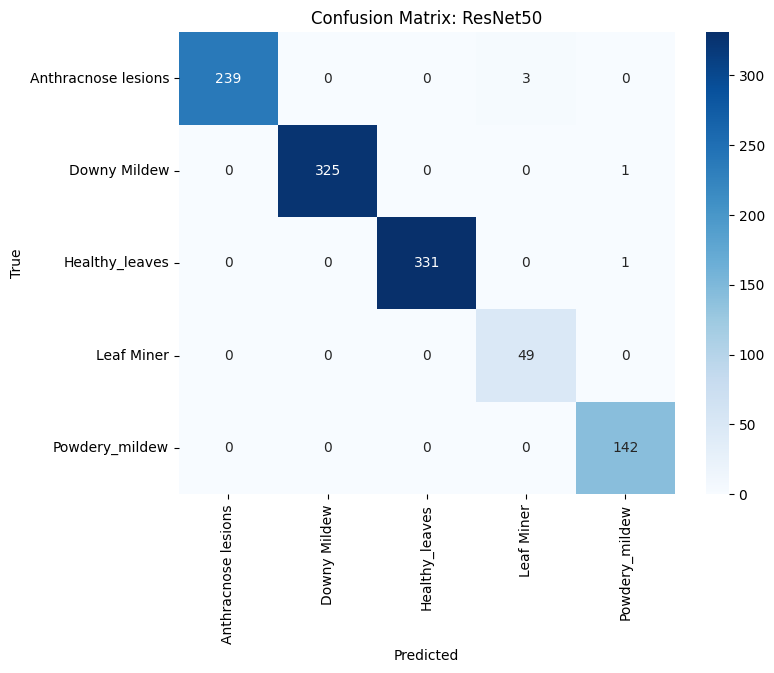

Evaluating InceptionV3...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 189MB/s]  


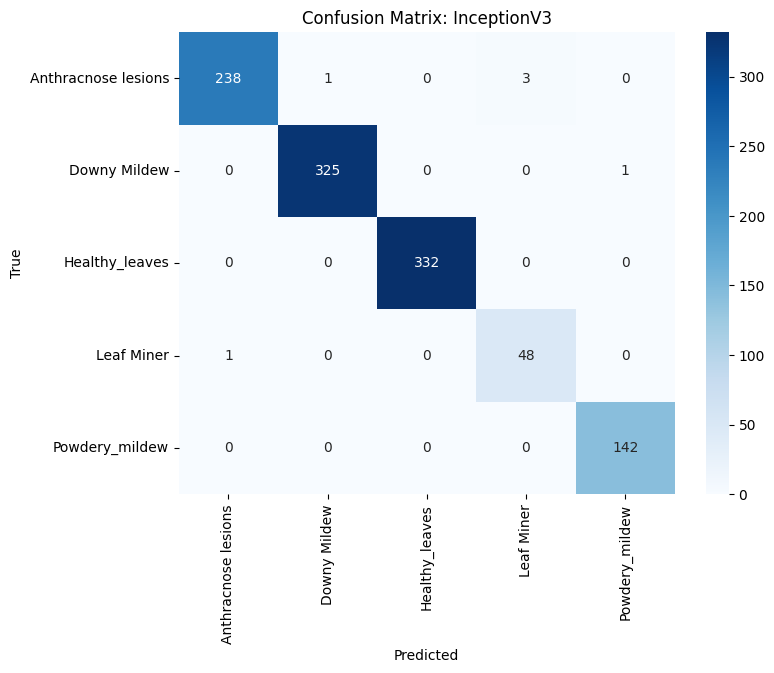

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Evaluating EfficientNetB0...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 137MB/s] 


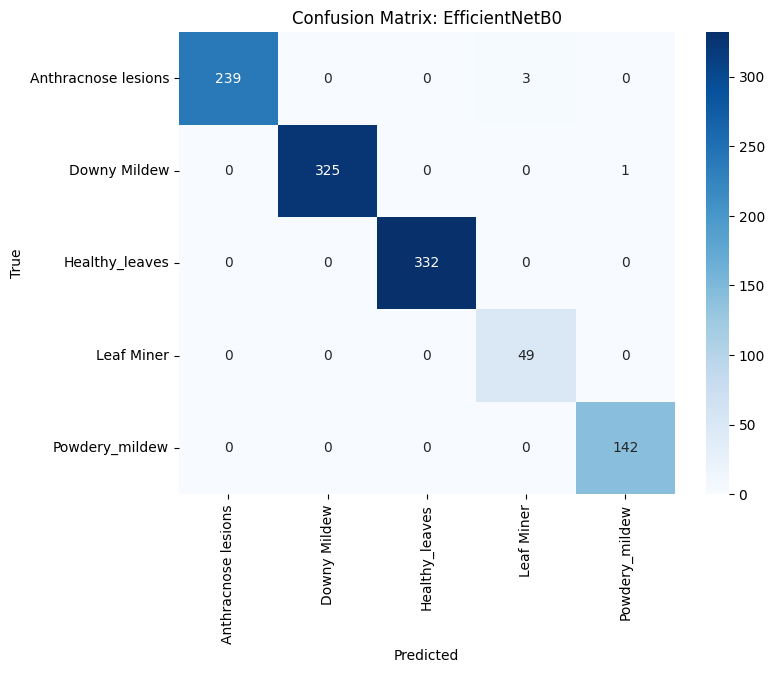

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Evaluating MobileNet...
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 102MB/s] 


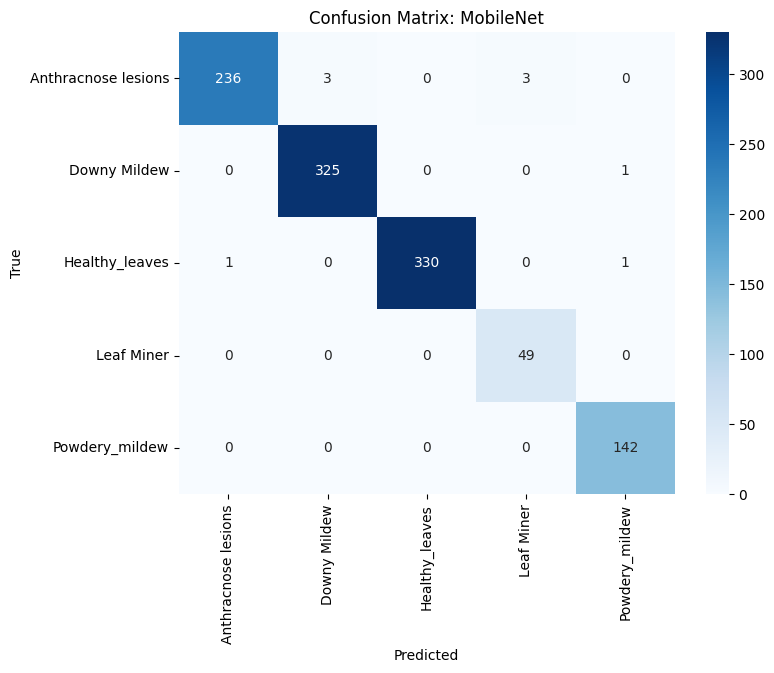

Evaluating Hybrid-1...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-d

Hybrid Logic: ResNet50 (2048) + InceptionV3 (2048) = 4096 features


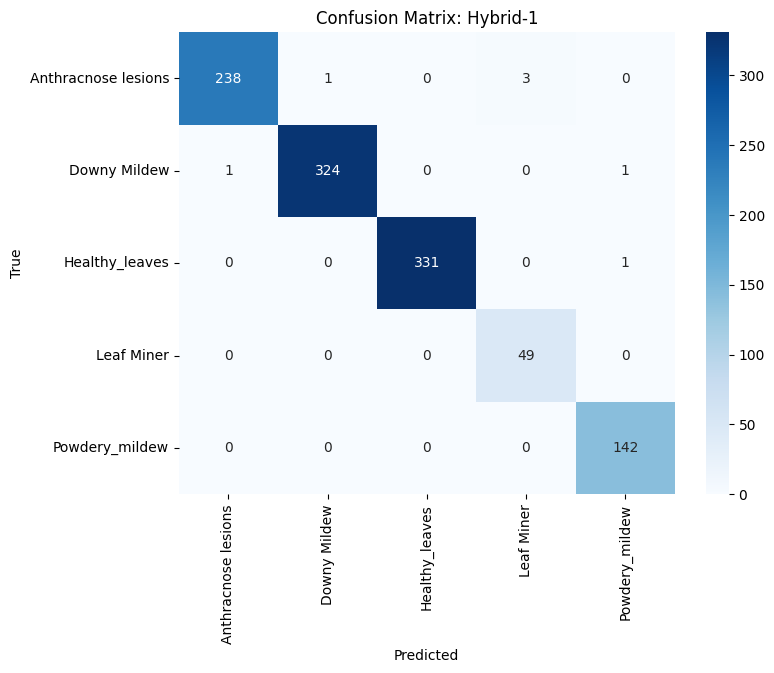

Evaluating Hybrid-2...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most u

Hybrid Logic: ResNet50 (2048) + EfficientNetB0 (1280) = 3328 features


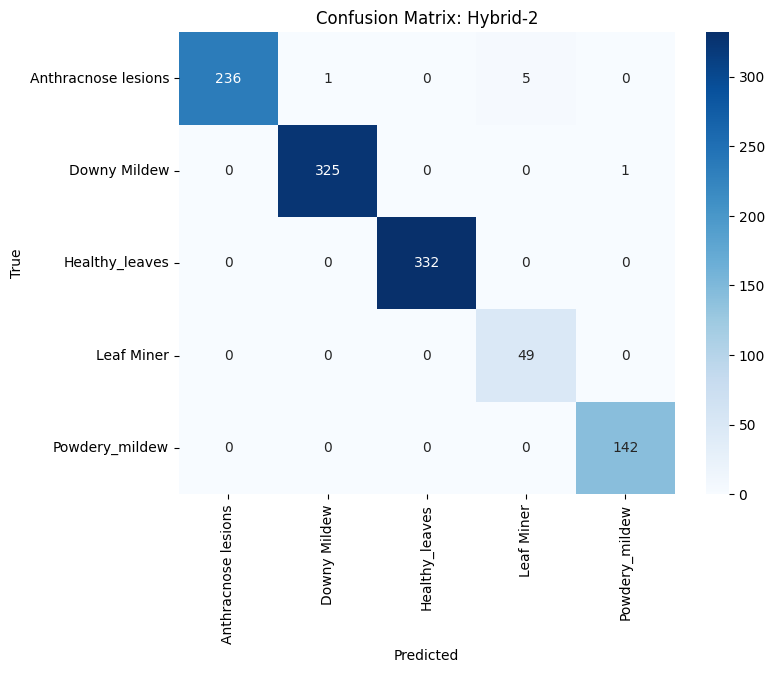

Evaluating Hybrid-3...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get th

Hybrid Logic: MobileNet (1280) + EfficientNetB0 (1280) = 2560 features


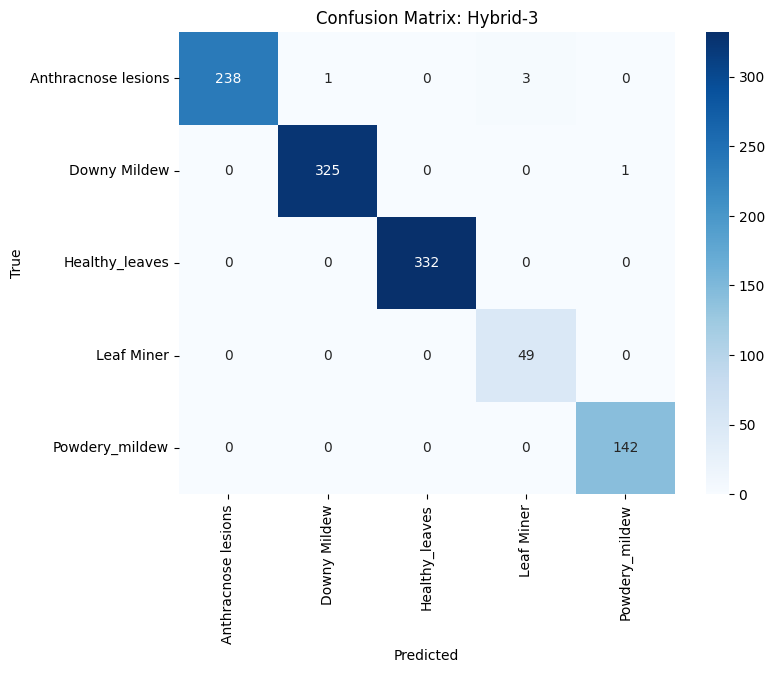


--- Model Comparison ---
            Model  Accuracy  Precision    Recall  F1 Score
0        ResNet50  0.995417   0.995601  0.995417  0.995454
1     InceptionV3  0.994500   0.994603  0.994500  0.994524
2  EfficientNetB0  0.996334   0.996499  0.996334  0.996367
3       MobileNet  0.991751   0.991932  0.991751  0.991767
4        Hybrid-1  0.993584   0.993754  0.993584  0.993614
5        Hybrid-2  0.993584   0.994015  0.993584  0.993662
6        Hybrid-3  0.995417   0.995582  0.995417  0.995444


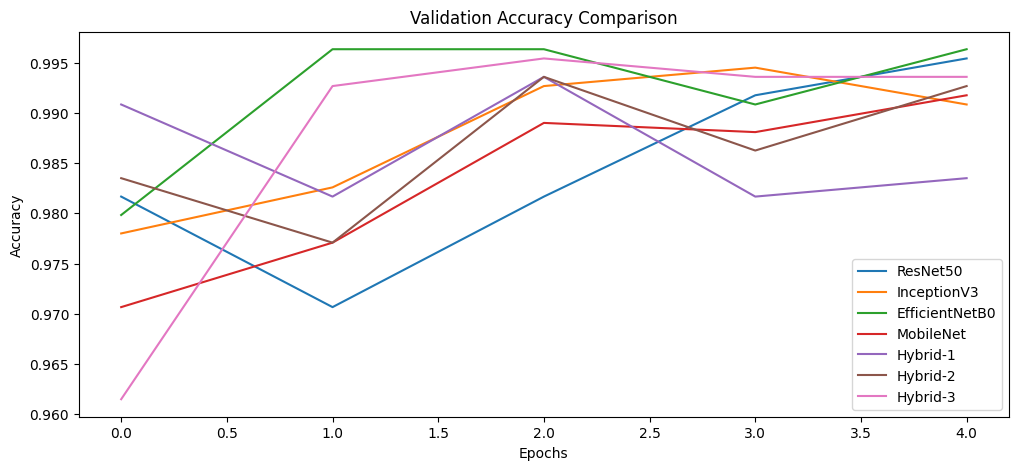

In [2]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import seaborn as sns
import pandas as pd

def evaluate_and_visualize(model_configs, val_loader, class_names):
    results_table = []
    
    for name, config in model_configs.items():
        print(f"Evaluating {name}...")
        
        # Re-instantiate and load weights
        if config == 'base':
            model = get_base_model(name, len(class_names))
        else:
            model = HybridModel(config[0], config[1], len(class_names))
            
        model.load_state_dict(torch.load(f"{name}_best.pth"))
        model.to(device)
        model.eval()
        
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.numpy())
        
        # Metrics
        acc = accuracy_score(all_labels, all_preds)
        p, r, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')
        
        results_table.append({
            'Model': name,
            'Accuracy': acc,
            'Precision': p,
            'Recall': r,
            'F1 Score': f1
        })

        
        # Confusion Matrix Plot
        plt.figure(figsize=(8, 6))
        cm = confusion_matrix(all_labels, all_preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
        plt.title(f'Confusion Matrix: {name}')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.show()

    # Comparison Table
    df_results = pd.DataFrame(results_table)
    print("\n--- Model Comparison ---")
    print(df_results)
    
    # Learning Curves Plotting (using stored histories)
    plt.figure(figsize=(12, 5))
    for name, hist in trained_histories.items():
        plt.plot(hist['val_acc'], label=f"{name}")
    plt.title("Validation Accuracy Comparison")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

# Run Evaluation
evaluate_and_visualize(model_configs, val_loader, class_names)

In [3]:
def predict_image(image_path, model_name, class_names):
    """
    Predict disease for a single image path using a specific trained model.
    """
    # 1. Prepare Model
    config = model_configs[model_name]
    if config == 'base':
        model = get_base_model(model_name, len(class_names))
    else:
        model = HybridModel(config[0], config[1], len(class_names))
        
    # Load weights
    try:
        model.load_state_dict(torch.load(f"{model_name}_best.pth", map_location=device))
    except FileNotFoundError:
        return f"Error: Weights for {model_name} not found."
        
    model.to(device)
    model.eval()
    
    # 2. Prepare Image
    transform = transforms.Compose([
        transforms.Resize((299, 299)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    try:
        image = Image.open(image_path).convert('RGB')
        image_tensor = transform(image).unsqueeze(0).to(device) # Add batch dim
    except Exception as e:
        return f"Error loading image: {e}"
    
    # 3. Predict
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted_idx = torch.max(probabilities, 1)
        
    predicted_label = class_names[predicted_idx.item()]
    conf_score = confidence.item() * 100
    
    return f"Prediction: {predicted_label} | Confidence: {conf_score:.2f}%"

# Example Usage:
# result = predict_image('/path/to/test_image.jpg', 'Hybrid-1 (ResNet+Inception)', class_names)
# print(result)

In [4]:
predict_image("/kaggle/input/datasets/spise/new-given-dataset/cucumber_Leaf_Disease11/test/Anthracnose lesions/DSC_6739 (Medium) (Medium) (Medium).JPG", "MobileNet", [
    'Anthracnose lesions', 
    'Downy Mildew', 
    'Healthy_leaves', 
    'Leaf Miner', 
    'Powdery_mildew'
])

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


'Prediction: Anthracnose lesions | Confidence: 99.97%'